### 2.Creating train and test dataloaders from the dataset

In [84]:
%cd "C:\Free code camp\fcc ml\going_modular_05\going_modular"

C:\Free code camp\fcc ml\going_modular_05\going_modular


In [85]:
%%writefile data_setup.py
"""
Contains functionality for creating PyTorch DataLoaders for 
image classification data.
"""
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = 0


def create_dataloaders(train_dir: str, test_dir: str,train_transform: transforms.Compose, 
test_transform:transforms.Compose, batch_size: int, num_workers: int = NUM_WORKERS):
    """ Creates training and testing dataloaders
    """
    # Using ImageFolder to create datasets
    train_data = datasets.ImageFolder(train_dir, transform=train_transform)   
    test_data = datasets.ImageFolder(test_dir, transform=test_transform)
    
    # Get class names
    class_names = train_data.classes
    class_dict = train_data.class_to_idx

    # Turn images into data loaders
    train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
    )
    test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False, # don't need to shuffle test data
      num_workers=num_workers,
      pin_memory=True,
    )

    return train_dataloader, test_dataloader, class_names,class_dict

Overwriting data_setup.py


### 3.Creating a tinyVGG model class

In [86]:
%%writefile model_builder.py
"""
Contains PyTorch model code to instantiate a TinyVGG model.
"""
import torch
from torch import nn 

class TinyVGG(nn.Module):
  """Creates the TinyVGG architecture.

  Replicates the TinyVGG architecture from the CNN explainer website in PyTorch.
  See the original architecture here: https://poloclub.github.io/cnn-explainer/

  Args:
    input_shape: An integer number of input channels.
    hidden_units: An integer number of hidden units between layers.
    output_shape: An integer number of output units.
  """
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
      super().__init__()
      self.conv_block_1 = nn.Sequential(
          nn.Conv2d(in_channels=input_shape, 
                    out_channels=hidden_units, 
                    kernel_size=3, 
                    stride=1, 
                    padding=0),  
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units, 
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=0),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,
                        stride=2)
      )
      self.conv_block_2 = nn.Sequential(
          nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
          nn.ReLU(),
          nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )
      self.classifier = nn.Sequential(
          nn.Flatten(),
          # Where did this in_features shape come from? 
          # It's because each layer of our network compresses and changes the shape of our inputs data.
          nn.Linear(in_features=hidden_units*13*13,
                    out_features=output_shape)
      )

  def forward(self, x: torch.Tensor):
      x = self.conv_block_1(x)
      x = self.conv_block_2(x)
      x = self.classifier(x)
      return x
      # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion




Overwriting model_builder.py


### 4..Creating `train_step()` and `test_Step()` functions and combining them into `train()` `engine.py`

In [87]:
%%writefile engine.py
"""
Contains functions for training and testing a PyTorch model.
"""
import torch

from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
  """Trains a PyTorch model for a single epoch.

  Turns a target PyTorch model to training mode and then
  runs through all of the required training steps (forward
  pass, loss calculation, optimizer step).

  Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy).
  """
  # Put model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate  and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item() 

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # Calculate and accumulate accuracy metric across all batches
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch 
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
  """Tests a PyTorch model for a single epoch.

  Turns a target PyTorch model to "eval" mode and then performs
  a forward pass on a testing dataset.

  Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
  """
  # Put model in eval mode
  model.eval() 

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
      # Loop through DataLoader batches
      for batch, (X, y) in enumerate(dataloader):
          # Send data to target device
          X, y = X.to(device), y.to(device)

          # 1. Forward pass
          test_pred_logits = model(X)

          # 2. Calculate and accumulate loss
          loss = loss_fn(test_pred_logits, y)
          test_loss += loss.item()

          # Calculate and accumulate accuracy
          test_pred_labels = test_pred_logits.argmax(dim=1)
          test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch 
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]} 
    For example if training for epochs=2: 
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]} 
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
      train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
      test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)

  # Return the filled results at the end of the epochs
  return results


Overwriting engine.py


### 5. Creating a function to save the model `utils.py`


In [88]:
%%writefile utils.py
"""
Contains various utility functions for PyTorch model training and saving.
"""
import torch
from pathlib import Path

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name: str):
  """Saves a PyTorch model to a target directory.

  Args:
    model: A target PyTorch model to save.
    target_dir: A directory for saving the model to.
    model_name: A filename for the saved model. Should include
      either ".pth" or ".pt" as the file extension.

  Example usage:
    save_model(model=model_0,
               target_dir="models",
               model_name="05_going_modular_tingvgg_model.pth")
  """
  # Create target directory
  target_dir_path = Path(target_dir)
  target_dir_path.mkdir(parents=True,
                        exist_ok=True)

  # Create model save path
  assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
  model_save_path = target_dir_path / model_name

  # Save the model state_dict()
  print(f"[INFO] Saving model to: {model_save_path}")
  torch.save(obj=model.state_dict(),
             f=model_save_path)

Overwriting utils.py


### 6. Training and Evalvuating and saving the model (`train.py`)

In [90]:
%%writefile train.py

"""
Trains a PyTorch image classification model using device-agnostic code.
"""
import os
import argparse
import torch
import data_setup, engine, model_builder, utils
from pred_plot import pred_plot_img as pred_plot

from torchvision import transforms

TEST_TRANSFORM = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.ToTensor()
])

TRAIN_TRANSFORM = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.TrivialAugmentWide(num_magnitude_bins=20),
  transforms.ToTensor()
])

PLOT_TRANSFORM = transforms.Compose([
  transforms.Resize((64,64),antialias= True)
  
])

# 1. Initialize the parser
parser = argparse.ArgumentParser(description="Train a TinyVGG model with custom hyperparameters.")

# 2. Add the arguments we want to be able to change
parser.add_argument("--num_epochs", default=5, type=int, help="Number of epochs to train for")
parser.add_argument("--batch_size", default=32, type=int, help="Number of samples per batch")
parser.add_argument("--hidden_units", default=10, type=int, help="Number of hidden units in the model")
parser.add_argument("--learning_rate", default=0.001, type=float, help="Learning rate for the optimizer")
parser.add_argument("--train_transform",default=TRAIN_TRANSFORM,type=transforms.Compose,help="Type of transforms to apply on training images")
parser.add_argument("--pred_img",default = r"C:\Free code camp\fcc ml\going_modular_05\data\images.jpeg",
type = str,help = "path of the image you want to make predictions on" )
# 3. Parse the arguments
args = parser.parse_args()

# Setup hyperparameters using the parsed arguments
NUM_EPOCHS = args.num_epochs
BATCH_SIZE = args.batch_size
HIDDEN_UNITS = args.hidden_units
LEARNING_RATE = args.learning_rate
TRAIN_TRANSFORM = args.train_transform
IMG_PATH =  r"C:\Free code camp\fcc ml\going_modular_05\data\images.jpeg"

print(f"[INFO]\nepochs : {NUM_EPOCHS}\nbatch size : {BATCH_SIZE}\nhidden units : {HIDDEN_UNITS}\nlearning rate : {LEARNING_RATE}\nTransforms : {TRAIN_TRANSFORM}")

# Setup directories 
train_dir = "../data/pizza_steak_sushi/train"
test_dir = "../data/pizza_steak_sushi/test"

# Setup target device
device = "cuda" if torch.cuda.is_available() else "cpu"



# Create DataLoaders with help from data_setup.py
train_dataloader, test_dataloader, class_names,class_dict = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    train_transform=TRAIN_TRANSFORM,
    test_transform = TEST_TRANSFORM,
    batch_size=BATCH_SIZE
)

# Create model with help from model_builder.py
model = model_builder.TinyVGG(
    input_shape=3,
    hidden_units=HIDDEN_UNITS,
    output_shape=len(class_names)
).to(device)

# Set loss and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE)

# Start training with help from engine.py
engine.train(model=model,
             train_dataloader=train_dataloader,
             test_dataloader=test_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             epochs=NUM_EPOCHS,
             device=device)

#making predictions on a random image
pred_plot(model = model,image_path = IMG_PATH,class_names = class_names,transform = PLOT_TRANSFORM,device = device )

# Save the model with help from utils.py
utils.save_model(model=model,
                 target_dir="models",
                 model_name="05_going_modular_script_mode_tinyvgg_model.pth")


Overwriting train.py


### 7. Function to plot predictions

In [91]:
%%writefile pred_plot.py
import torch
import torchvision
import matplotlib.pyplot as plt



def pred_plot_img(model:torch.nn.Module,image_path:str,class_names:list[str] = None,transform = None,device: str = "cuda" if torch.cuda.is_available() else "cpu"):
    """Makes a prediction on a target image with a trained model and plots the image and the predcition"""
    #Loading an image
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    #Divide the image pixel value by 255 to get them between [0,1]
    target_image  = target_image / 255.

    #Transform the data if neccessary 
    if transform:
        target_image = transform(target_image)

    #The model should be on the same device
    model.to(device)

    #Turn the moodel to eval mode
    model.eval()
    with torch.inference_mode():
        #Add an extra dimension to the image i.e Batch_size since it is an image that is taken from outside the dataset 
        target_image = target_image.unsqueeze(0)

        #Making a prediciton with an extra dimension
        target_img_pred = model(target_image.to(device)) #Make sure the image and the model are on the same device

        #Convert logits into probabilites
        target_img_pred_probs = torch.softmax(target_img_pred,dim = 1)

        #Convert prediction probabilites 
        target_img_pred_labels = torch.argmax(target_img_pred_probs, dim = 1)

        #plot the image alongside the prediction and prediction probabilites
        #Removing the batch dimension and rearrgeing the dim to HWC
        plt.imshow(target_image.squeeze().permute(1,2,0))

        if class_names:
            title = f"Pred : {class_names[target_img_pred_labels.item()]} | Prob : {target_img_pred_probs.max().item():.3f}"
        else:
            title = f"Pred : {target_img_pred_labels} | Prob : {target_img_pred_probs.max().cpu():.3f}"

        plt.title(title)
        plt.axis(False)


Overwriting pred_plot.py


### 8. Function to plot confusion matrix `conf_mat.py`

In [110]:
%%writefile conf_mat.py

import argparse
import torch
from torchvision import transforms
from tqdm.auto import tqdm
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
import data_setup,model_builder
import matplotlib.pyplot as plt
parser = argparse.ArgumentParser(description="Plots a confusion matrix for a saved model")
parser.add_argument("--model_path", type=str, required=True, help="Path to the saved model .pth file")
parser.add_argument("--batch_size", type=int, default=32, help="Batch size for testing data")
parser.add_argument("--hidden_units", type=int, default=20, help="Hidden units used when training the model")
args = parser.parse_args()

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    TEST_TRANSFORM = transforms.Compose([
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ])
    TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=20),
    transforms.ToTensor()
    ])

    train_dir = "../data/pizza_steak_sushi/train"
    test_dir = "../data/pizza_steak_sushi/test"

    print("[INFO] Loading testing data..")

    _,test_dataloader,class_names,_ = data_setup.create_dataloaders(
        train_dir = train_dir,
        test_dir = test_dir,
        train_transform = TRAIN_TRANSFORM,
        test_transform = TEST_TRANSFORM,
        batch_size = args.batch_size
    )


    print(f"[INFO] Instantiating TinyVGG model with {args.hidden_units} hidden units...")
    model = model_builder.TinyVGG(
        input_shape=3,
        hidden_units=args.hidden_units,
        output_shape=len(class_names)
    )

    print(f"[INFO] Loading weights from: {args.model_path}")
    model.load_state_dict(torch.load(args.model_path, map_location=device))
    model.to(device)
    model.eval()

    
    y_preds = []
    y_true = []
    print("[INFO] Running inference on test dataset...")
    with torch.inference_mode():
        for X, y in tqdm(test_dataloader, desc="Making predictions"):
            X, y = X.to(device), y.to(device)
            y_logit = model(X)
            y_pred = torch.argmax(torch.softmax(y_logit, dim=1), dim=1)
            
            # Move to CPU immediately for matplotlib/mlxtend compatibility
            y_preds.append(y_pred.cpu())
            y_true.append(y.cpu())

    y_preds_tensor = torch.cat(y_preds)
    y_true_tensor = torch.cat(y_true)

    print("[INFO] Generating Confusion Matrix plot...")
    confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
    confmat_tensor = confmat(preds=y_preds_tensor, target=y_true_tensor)

    fig, ax = plot_confusion_matrix(
        conf_mat=confmat_tensor.numpy(),
        class_names=class_names,
        figsize=(10, 7),
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix: {model.__class__.__name__}", fontsize=14)
    plt.show()

if __name__ == "__main__":
    main()

Overwriting conf_mat.py


[INFO]
epochs : 50
batch size : 32
hidden units : 30
learning rate : 0.001
Transforms : Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    TrivialAugmentWide(num_magnitude_bins=20, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
)


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1004 | train_acc: 0.3555 | test_loss: 1.1025 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.1046 | train_acc: 0.3047 | test_loss: 1.1022 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0813 | train_acc: 0.3438 | test_loss: 1.0938 | test_acc: 0.3002
Epoch: 4 | train_loss: 1.0693 | train_acc: 0.4688 | test_loss: 1.0524 | test_acc: 0.5436
Epoch: 5 | train_loss: 1.0742 | train_acc: 0.3711 | test_loss: 1.0355 | test_acc: 0.4318
Epoch: 6 | train_loss: 0.9985 | train_acc: 0.4922 | test_loss: 0.9866 | test_acc: 0.5739
Epoch: 7 | train_loss: 0.9891 | train_acc: 0.5508 | test_loss: 0.9920 | test_acc: 0.3617
Epoch: 8 | train_loss: 0.9226 | train_acc: 0.5977 | test_loss: 1.0450 | test_acc: 0.3523
Epoch: 9 | train_loss: 1.0244 | train_acc: 0.4492 | test_loss: 1.0171 | test_acc: 0.4242
Epoch: 10 | train_loss: 0.9011 | train_acc: 0.5938 | test_loss: 1.0178 | test_acc: 0.3835
Epoch: 11 | train_loss: 0.9310 | train_acc: 0.4805 | test_loss: 0.9892 | test_acc: 0.3741
Epoch: 12 | train_l

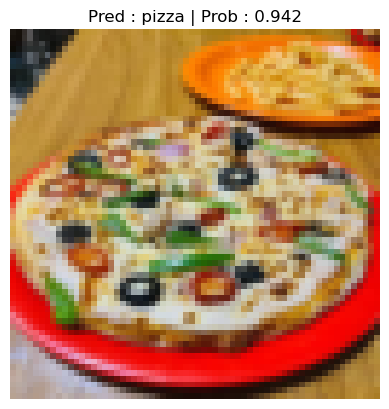

In [112]:
%run train.py --num_epochs 50 --batch_size 32 --hidden_units 30

[INFO] Loading testing data..
[INFO] Instantiating TinyVGG model with 30 hidden units...
[INFO] Loading weights from: C:\Free code camp\fcc ml\going_modular_05\going_modular\models\05_going_modular_script_mode_tinyvgg_model.pth
[INFO] Running inference on test dataset...


C:\Free code camp\fcc ml\going_modular_05\going_modular\conf_mat.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(args.model_path, map_l

Making predictions:   0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Generating Confusion Matrix plot...


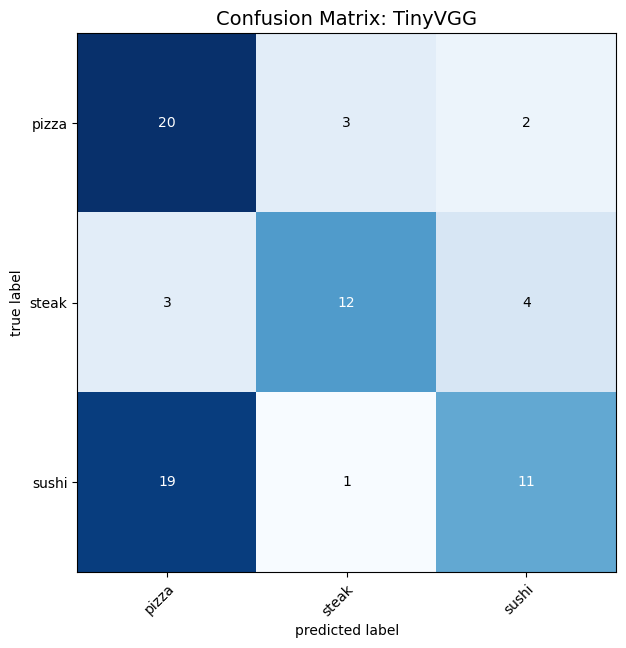

In [113]:
%run conf_mat.py --model_path "C:\Free code camp\fcc ml\going_modular_05\going_modular\models\05_going_modular_script_mode_tinyvgg_model.pth" --hidden_units 30